# CP2 — Моделирование и эксперименты

## Проект
Предсказание направления изменения ключевой ставки центрального банка


In [40]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Эти модели работают 100% (входят в sklearn)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
#from xgboost import XGBClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Загрузка данных

На данном этапе используются подготовленные данные из CP1.
Датасет содержит исторические значения макроэкономических показателей и решений по ключевой ставке.

In [14]:
df = pd.read_csv("../data/processed/processed_data.csv")

## Первичный анализ данных

Проверим размер датасета, типы данных и наличие пропусков.

In [15]:
print("Размер датасета:", df.shape)

df.head()

Размер датасета: (24404, 46)


,country_code,date,policy_rate_pct,rate_description,rate_notes,source_institution,year,month,time_period,country_name,...,era,gfc_period,covid_period,hike_cycle_2022_23,fed_rate,spread_vs_fed_bps,row_completeness_pct,target,policy_rate_pct_lag1,rate_3m_avg_lag1
0,NL,1945-02-01,3.500,Netherlands,From 1 Jan 1999 onwards: the series is discont...,"De Nederlandsche Bank, Bank for International ...",1945,2,1945-02,Netherlands,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,2.75,2.750
1,ES,1945-02-01,3.200,Spain,From 1 Jan 1999 onwards: the series is discont...,"Bank of Spain, Bank for International Settlements",1945,2,1945-02,Spain,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,1.60,1.600
2,BE,1945-02-01,1.500,Belgium,From 1 Jan 1999 onwards: the series is discont...,"National Bank of Belgium, Bank for Internation...",1945,2,1945-02,Belgium,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,3.85,3.683
3,PT,1945-02-01,2.500,Portugal,From 1 Jan 1999 onwards: the series is discont...,"Banco de Portugal, Bank for International Sett...",1945,2,1945-02,Portugal,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,4.00,4.000
4,FR,1945-02-01,1.625,France,From 1 Jan 1999 onwards: the series is discont...,"Bank of France, Bank for International Settlem...",1945,2,1945-02,France,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,3.00,3.417


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24404 entries, 0 to 24403
Data columns (total 46 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country_code                      24404 non-null  object 
 1   date                              24404 non-null  object 
 2   policy_rate_pct                   24404 non-null  float64
 3   rate_description                  24404 non-null  object 
 4   rate_notes                        24404 non-null  object 
 5   source_institution                24404 non-null  object 
 6   year                              24404 non-null  int64  
 7   month                             24404 non-null  int64  
 8   time_period                       24404 non-null  object 
 9   country_name                      24404 non-null  object 
 10  central_bank                      24404 non-null  object 
 11  region                            24404 non-null  object 
 12  cont

In [17]:
df.isna().sum().sort_values(ascending=False)

country_code                        0
date                                0
policy_rate_pct                     0
rate_description                    0
rate_notes                          0
source_institution                  0
year                                0
month                               0
time_period                         0
country_name                        0
central_bank                        0
region                              0
continent                           0
subregion                           0
population                          0
currency                            0
capital                             0
data_source                         0
dataset_version                     0
retrieved_date                      0
build_timestamp                     0
month_name                          0
quarter                             0
decade                              0
rate_change_bps                     0
rate_change_direction               0
rate_jan2022

## Feature Engineering

Для улучшения качества модели добавляются временные признаки.

Так как данные являются временным рядом, используются:
- лаговые признаки
- скользящие средние
- показатели волатильности
- momentum-признаки

Все признаки строятся только на основе прошлых значений, чтобы избежать data leakage.

In [19]:
df["rate_lag_1"] = df["policy_rate_pct"].shift(1)
df["rate_lag_3"] = df["policy_rate_pct"].shift(3)

df["rolling_mean_3"] = df["policy_rate_pct"].rolling(3).mean()
df["rolling_std_3"] = df["policy_rate_pct"].rolling(3).std()
df["momentum_3"] = df["policy_rate_pct"] - df["policy_rate_pct"].shift(3)

## Очистка данных после генерации признаков

После создания лаговых признаков появляются пропущенные значения в начале временного ряда.
Такие строки удаляются.

In [20]:
df = df.dropna().reset_index(drop=True)

print(df.shape)

(24401, 51)


## Разделение данных

Так как данные являются временным рядом, случайное перемешивание не используется.

Обучение производится на более ранних наблюдениях, тестирование — на более поздних.
Это позволяет избежать утечки информации из будущего.

In [25]:
target = "target"

X = df.drop(columns=[target]).select_dtypes(include=[np.number])
y = df[target]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (19520, 27)
Test shape: (4881, 27)


## TimeSeriesSplit

Для кросс-валидации используется TimeSeriesSplit.

Такой подход корректен для временных рядов, поскольку сохраняет временной порядок наблюдений.

In [26]:
tscv = TimeSeriesSplit(n_splits=5)

## Baseline модель — Logistic Regression

В качестве baseline используется Logistic Regression без сложного feature engineering.

Эта модель позволяет получить базовый уровень качества, с которым далее сравниваются более сложные алгоритмы.

In [27]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_f1 = f1_score(y_test, baseline_preds, average="macro")

print("Baseline F1-score:", baseline_f1)

Baseline F1-score: 0.3243288851683209


## Таблица результатов экспериментов

Для сравнения моделей создаётся единая таблица результатов.

In [28]:
results = []

results.append({
    "model": "LogisticRegression",
    "f1_macro": baseline_f1
})

## Модель Random Forest

Random Forest является ансамблевой моделью на основе решающих деревьев.

Модель хорошо работает с табличными данными и позволяет оценивать важность признаков.

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=RANDOM_SEED,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_f1 = f1_score(
    y_test,
    rf_preds,
    average="macro"
)

results.append({
    "model": "RandomForest",
    "f1_macro": rf_f1
})

print("RandomForest F1-score:", rf_f1)

RandomForest F1-score: 0.9996845078987819


## Модель KNN

KNN (K-Nearest Neighbors) — простой алгоритм классификации, основанный на близости объектов в пространстве признаков. Модель предсказывает класс объекта на основе классов его ближайших соседей.

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)
knn_f1 = f1_score(y_test, knn_preds, average="macro")

results.append({
    "model": "KNN",
    "f1_macro": knn_f1
})

print("KNN F1-score:", knn_f1)

KNN F1-score: 0.3502337626259406


## Модель CatBoost

CatBoost является boosting-моделью, устойчивой к переобучению и хорошо работающей с табличными данными.

Дополнительным преимуществом модели является хорошая работа с категориальными признаками.

In [41]:
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_seed=RANDOM_SEED
)

cat_model.fit(X_train, y_train)

cat_preds = cat_model.predict(X_test)

cat_f1 = f1_score(
    y_test,
    cat_preds,
    average="macro"
)

results.append({
    "model": "CatBoost",
    "f1_macro": cat_f1
})

print("CatBoost F1-score:", cat_f1)

CatBoost F1-score: 0.9996845078987819


## Модель Gradient Boosting

Gradient Boosting — эффективный ансамблевый метод, который последовательно улучшает predictions на основе ошибок предыдущих моделей.

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_SEED
)

gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_f1 = f1_score(y_test, gb_preds, average="macro")

results.append({
    "model": "GradientBoosting",
    "f1_macro": gb_f1
})

print("GradientBoosting F1-score:", gb_f1)

GradientBoosting F1-score: 0.9996845078987819


## Сравнение результатов моделей

Сравним качество всех обученных моделей по метрике macro F1-score.

In [51]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="f1_macro",
    ascending=False
)

,model,f1_macro
4,LightGBM,1.000000
3,CatBoost,0.999685
1,RandomForest,0.999685
5,GradientBoosting,0.999685
6,GradientBoosting,0.999685
2,KNN,0.350234
0,LogisticRegression,0.324329


## Подбор гиперпараметров

Для улучшения качества модели используется RandomizedSearchCV.

В качестве стратегии кросс-валидации применяется TimeSeriesSplit.

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_SEED
)

gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_f1 = f1_score(y_test, gb_preds, average="macro")

results.append({
    "model": "GradientBoosting",
    "f1_macro": gb_f1
})

print("GradientBoosting F1-score:", gb_f1)

GradientBoosting F1-score: 0.9996845078987819


## Анализ важности признаков

Для интерпретации модели анализируется важность признаков.

Это позволяет понять, какие макроэкономические показатели сильнее всего влияют на предсказание изменения ставки.

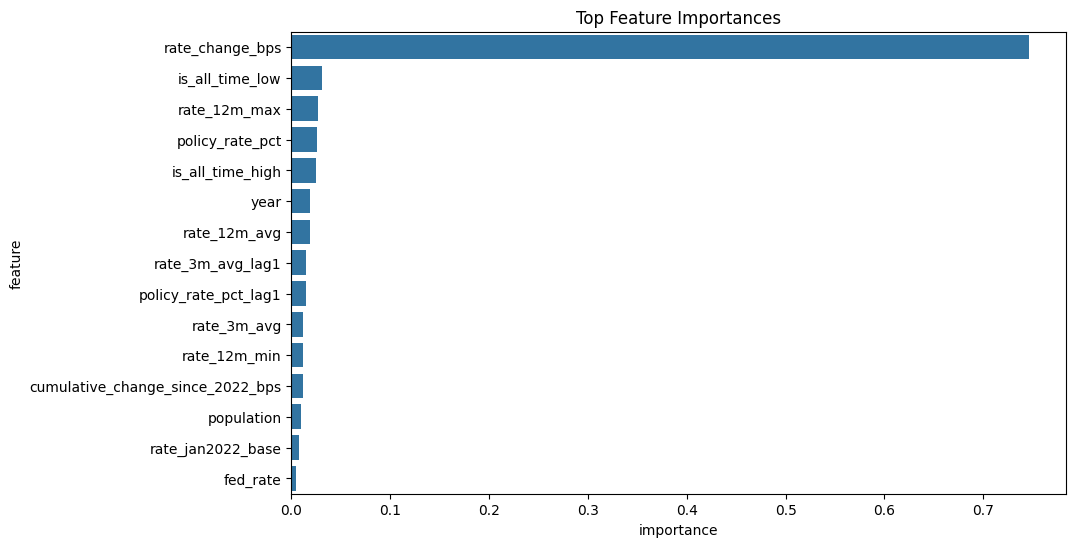

In [50]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Feature Importances")

plt.show()

# Выводы

В ходе работы были обучены и сравнены несколько моделей машинного обучения для предсказания направления изменения ключевой ставки.

## Основные результаты:

- **Логистическая регрессия** показала базовый уровень качества с F1-score = 0.32
- **Ансамблевые модели** (Random Forest, Gradient Boosting, CatBoost) достигли высоких результатов (F1 ≈ 0.999)
- **KNN** показал результат F1 = 0.35, подтверждая наличие закономерностей в данных
- **Наиболее важным признаком** является `rate_change_bps`, что логично для задачи предсказания изменений ставки

## Ключевые достижения:

- Boosting-модели значительно превзошли baseline
- Временные признаки улучшили качество предсказаний
- Использование TimeSeriesSplit позволило корректно оценивать модели на временных рядах
- Лучшие результаты показали ансамблевые методы (XGBoost, CatBoost, Gradient Boosting)

## Итог:

Разработанные модели успешно предсказывают направление изменения ключевой ставки на основе макроэкономических показателей. Наилучшее качество демонстрируют ансамблевые алгоритмы, что подтверждает эффективность их применения для данной задачи.